# ML-DSA (CRYSTALS-Dilithium) 강의 노트북
## 격자 기반 전자서명 — Fiat-Shamir with Aborts (FIPS 204)

---

이 노트북은 **양자내성 전자서명 ML-DSA(CRYSTALS-Dilithium)를 처음 배우는 분**을 위한 강의 자료입니다. 수학 전공 지식이 없어도 따라올 수 있도록, 수식 대신 비유와 일상 언어로 설명합니다.

전자서명을 한마디로 하면 **"위조할 수 없는 도장 찍기"**입니다. 내가 나만의 도장(비밀키)으로 문서에 자국을 남기면, 받은 사람은 누구나 공개된 도장 견본(공개키)과 대조해 "정말 그 사람이 찍었는지, 문서가 중간에 바뀌지 않았는지"를 확인할 수 있습니다. ML-DSA는 이 도장을 양자컴퓨터로도 베낄 수 없도록 격자(수많은 점이 규칙적으로 늘어선 수학 구조) 문제 위에 새로 만든 서명 방식입니다.

이 노트북은 이론 설명 → 밑바닥(numpy) Mini-Dilithium 구현 → 서명 검증·위조 거부 실험 → 재시도(abort) 분포 분석 → 실무 적용성 판단 순서로 진행하며, **"찍은 도장에 비밀 흔적이 비치면 찢어 버리고 다시 찍는" Fiat-Shamir with Aborts 구조**가 실제로 어떻게 동작하는지 눈으로 확인합니다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 ML-DSA(Dilithium) 주제를 분리·정리한 강의 자료입니다.
> 실행 셀과 출력은 원본 그대로이며, 재실행하려면 **0장(Setup)의 공통 설정 셀을 먼저 실행**해야 합니다.

### 학습 목표
1. 전자서명이 KEM(키 교환, 비밀번호를 몰래 나눠 갖는 기술)과 무엇이 다른지, 그리고 어떤 것을 보장하는지 — 인증(진짜 보낸 사람 확인), 무결성(내용이 안 바뀜), 부인방지(나중에 "내가 안 보냈다"고 발뺌 못 함) — 를 이해한다.
2. 도장 찍기(서명 생성)가 "가림막 뽑기 → 도장 자국 만들기 → 확인 질문 받기 → 응답 내보내기"의 네 단계로 이루어짐을 안다.
3. 응답이 너무 크면 **버리고 다시 찍는(abort)** 이유 — 비밀 재료의 누출 차단 — 를 설명할 수 있다.
4. HighBits(상위 비트만 비교하기) 기법이 작은 오차는 눈감아 주면서도 위조는 잡아내는 원리를 이해한다.
5. 크기를 줄인 연습용 파라미터의 Mini-Dilithium으로 정상 검증·위조 거부·재시도 횟수를 직접 실측한다.
6. FIPS 204 표준 현황과 실무 적용처(코드 서명·PKI 등)를 판단할 수 있다.

> **선행 지식**: 파이썬 코드를 대략 읽을 수 있고, "해시 함수 = 어떤 데이터든 고정 길이의 지문으로 바꾸는 기계"라는 것만 알면 충분합니다. 격자 암호를 처음 보셔도 괜찮습니다 — 필요한 개념은 본문에서 그때그때 풀어 설명합니다.

## 0. 준비 (Setup)

아래 공통 설정 셀(Harness, 실험용 도구 상자)은 통합본 전체에서 공유하는 도구 모음입니다. 이 노트북의 모든 코드 셀보다 **먼저 실행**해야 합니다.

- 재현성 시드(`RNG`): 난수를 매번 똑같이 나오게 고정해서, 누가 실행해도 같은 실험 결과가 재현되도록 하는 장치입니다. 그래프의 한글 폰트도 자동 설정합니다.
- 해시 헬퍼 `H`(SHA-256), `shake`(SHAKE-128): 어떤 데이터든 고정 길이의 "지문"으로 바꾸는 함수로, 도전값(챌린지, 서명 과정에서 나오는 확인 질문) 생성 등에 사용합니다.
- `nbytes`: 키·서명을 바이트로 바꿔 "전송하면 몇 바이트나 되는지" 대략 재는 함수입니다.
- `timeit`: 실행 시간 측정, `log_metric`: 알고리즘 간 종합 비교용 수치 저장소입니다.

> 그래프(matplotlib) 안의 텍스트는 폰트 호환을 위해 영어로 표기합니다.

In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. 이론 — 전자서명과 Fiat-Shamir with Aborts

### 1-1. 전자서명의 역할

앞서 배운 KEM이 "두 사람이 몰래 비밀번호를 나눠 갖는 방법"이라면, **전자서명은 "이 문서는 내가 보냈고, 중간에 아무도 고치지 않았다"를 증명하는 방법**입니다.

종이 문서에 찍는 도장을 떠올려 보세요.

- **도장 찍기(서명 생성)**: 나만 가진 도장(비밀키)으로 문서에 자국을 남깁니다.
- **도장 확인(서명 검증)**: 받은 사람은 공개된 도장 견본(공개키)과 대조해 진짜인지 누구나 확인할 수 있습니다.

ML-DSA는 이 도장을 양자컴퓨터로도 베낄 수 없게 격자 문제 위에 다시 만든 것으로, 오늘날 RSA·ECDSA 서명이 쓰이는 자리를 그대로 대체합니다.

### 1-2. Fiat-Shamir with Aborts — "비치면 찢고 다시 찍기"

ML-DSA가 쓰는 방식의 이름은 **Fiat-Shamir with Aborts**(Lyubashevsky)입니다. 이름은 어렵지만 핵심은 한 문장입니다.

> **찍은 도장에 비밀 재료의 흔적이 비쳐 보일 것 같으면, 그 도장은 찢어 버리고 처음부터 다시 찍는다.**

서명 하나는 다음 네 단계로 만들어집니다.

1. **가림막 뽑기**: 이번 서명에만 쓰고 버릴 일회용 난수 y(가림막)를 뽑습니다.
2. **커밋(값을 먼저 약속해 두기)과 챌린지(확인 질문)**: y로 도장 자국 w를 만들고, 그 상위 비트(큰 자릿수 부분)와 메시지를 함께 해시에 넣어 도전값 c를 만듭니다. c는 "메시지가 스스로 정한 확인 질문"인 셈입니다.
3. **응답 내보내기**: 아래 한 줄이 이 서명 방식의 심장입니다.

$$ z = y + c \cdot s_1 $$

> **수식 풀이:** s₁은 도장의 **비밀 재료**(비밀키), c는 메시지가 정한 **확인 질문**, y는 이번에만 쓰는 **가림막**입니다. z는 "비밀 재료에 확인 질문을 섞은 값 위에 가림막을 덮어 내보내는 응답"입니다. 가림막 y가 충분히 두꺼우면, 받는 사람은 z만 보고는 비밀 재료 s₁을 알아낼 수 없습니다.

4. **위험하면 버리기(abort, 중단)**: 계산된 z가 너무 크면 가림막이 얇아진 것과 같아서 비밀 재료가 비쳐 보일 수 있습니다. 그런 서명은 내보내지 않고 버린 뒤 1번부터 다시 시작합니다. 이 **중단(abort)**이 안전성의 핵심입니다.

**검증(도장 확인)**: 확인하는 사람은 도장 견본(공개키)과 서명(z, c)만 가지고 서명 당시의 도장 자국 w를 (작은 오차 범위 안에서) 되살릴 수 있습니다. 되살린 자국의 상위 비트로 확인 질문 c를 다시 만들어 보고, 서명 속의 c와 똑같이 나오면 "진짜 도장"으로 판정합니다.

> **HighBits(상위 비트만 비교) 기법**: 되살린 자국은 원본과 정확히 같지 않고 아주 조금 어긋납니다. 그래서 자잘한 아랫자리(하위 비트)는 눈감아 주고 **큰 자릿수(상위 비트)만 비교**합니다. 사진을 흐릿하게 축소해 비교하면 미세한 얼룩은 무시되지만 전혀 다른 사진은 바로 구별되는 것과 같은 원리입니다.

### 1-3. 실험 설계

이번 장의 실험 목표는 세 가지입니다.

1. 정상적으로 찍은 도장(서명)이 확인을 통과하는지 반복해서 확인합니다.
2. **메시지를 한 글자만 바꾼 위조**가 거부되는지 확인합니다.
3. 서명 한 건을 완성할 때까지 몇 번이나 찢고 다시 찍었는지(재시도 횟수)를 기록합니다 — 크기를 줄인 연습용 파라미터라서 실제 표준보다 재시도가 잦은 모습을 관찰할 수 있습니다.

## 2. 밑바닥 구현 — Mini-Dilithium

다음 셀은 실제 표준보다 크기를 확 줄인 연습용 파라미터(다항식 길이 n=16, 계산에 쓰는 나머지 기준 수 q=3329, 행렬 크기 k=ℓ=2)로 Mini-Dilithium의 키 생성(`dsa_keygen`) · 서명(`dsa_sign`) · 검증(`dsa_verify`)을 구현하고,
120회 반복 실험으로 정상 검증 통과율·변조 거부율·서명당 재시도 횟수·키/서명 크기를 측정합니다.

코드에 나오는 상수의 뜻은 다음과 같습니다.

| 상수 | 값 | 쉬운 설명 |
|---|---|---|
| `DETA` | 2 | 비밀 재료(비밀키)의 숫자를 얼마나 작게 뽑을지 정하는 폭 |
| `DGAMMA` | 1024 | 가림막 y의 두께 — 클수록 비밀을 잘 가립니다 |
| `DBETA` | 48 | "비쳐 보임" 판정의 여유 폭 — 응답 z의 가장 큰 값이 한계선(DGAMMA − DBETA)에 닿으면 찢고 다시 찍습니다 |
| `DGAMMA2` | 128 | 상위 비트만 남길 때의 반올림 단위 |

서명 루프 안에는 "찢고 다시 찍기(abort)" 조건이 **두 개** 있습니다. ⑴ 응답 z가 안전 범위를 벗어나 비밀이 비쳐 보일 위험이 있는 경우, ⑵ 확인하는 쪽이 되살릴 도장 자국의 상위 비트가 원본과 어긋나 정상 서명인데도 확인에 실패할 경우입니다. 둘 중 하나라도 걸리면 그 서명은 버리고 처음부터 다시 만듭니다.

In [12]:
# ③ 밑바닥 구현 — Mini-Dilithium (Fiat-Shamir with aborts)
DN, DQ, DK, DL = 16, 3329, 2, 2
DETA, DGAMMA, DBETA, DGAMMA2 = 2, 1024, 48, 128   # 오차폭/난수폭/여유/상위비트 반올림 단위

def dpmul(a, b):
    r = np.zeros(2 * DN - 1, dtype=np.int64)
    for i in range(DN):
        r[i:i + DN] += a[i] * b
    out = r[:DN].copy(); out[:DN - 1] -= r[DN:2 * DN - 1]
    return ((out + DQ // 2) % DQ) - DQ // 2       # 중앙 정규화 [-q/2, q/2)
dadd = lambda a, b: ((a + b + DQ // 2) % DQ) - DQ // 2
dsub = lambda a, b: ((a - b + DQ // 2) % DQ) - DQ // 2
dsmall = lambda rng: rng.integers(-DETA, DETA + 1, size=DN)
def inf_norm(v): return max(int(np.max(np.abs(p))) for p in v) if v else 0

def highbits(poly):
    """하위 비트를 버림 → 작은 오차(c·s2)에 견고한 상위 비트"""
    return np.round((poly % DQ) / DGAMMA2).astype(np.int64)
def hi_to_bytes(w): return b''.join(highbits(wi).tobytes() for wi in w)

def dmatvec(Amat, s, rows, cols):
    return [np.sum([dpmul(Amat[i][j], s[j]) for j in range(cols)], axis=0) for i in range(rows)]

def challenge(hi_bytes, msg):
    h = hashlib.shake_128(msg + hi_bytes).digest(64)   # 상위비트+메시지 → 희소 ±1 다항식
    c = np.zeros(DN, dtype=np.int64)
    for i in range(DN):
        c[i] = (1 if h[i] & 1 else -1) if h[i] < 80 else 0
    return c

def dsa_keygen(rng):
    Amat = [[rng.integers(0, DQ, size=DN) - DQ // 2 for _ in range(DL)] for _ in range(DK)]
    s1 = [dsmall(rng) for _ in range(DL)]
    s2 = [dsmall(rng) for _ in range(DK)]
    t = [dadd(dmatvec(Amat, s1, DK, DL)[i], s2[i]) for i in range(DK)]
    return (Amat, t), (s1, s2)

def dsa_sign(msg, pk, sk, rng):
    Amat, t = pk; s1, s2 = sk
    tries = 0
    for _ in range(600):
        tries += 1
        y = [rng.integers(-DGAMMA, DGAMMA + 1, size=DN) for _ in range(DL)]
        w = dmatvec(Amat, y, DK, DL)
        c = challenge(hi_to_bytes(w), msg)
        z = [dadd(y[i], dpmul(c, s1[i])) for i in range(DL)]
        if inf_norm(z) >= DGAMMA - DBETA:                 # 응답이 크면 비밀 누출 위험 → 중단
            continue
        w2 = [dsub(w[i], dpmul(c, s2[i])) for i in range(DK)]   # 검증자가 볼 값 미리 확인
        if any(not np.array_equal(highbits(w[i]), highbits(w2[i])) for i in range(DK)):
            continue                                       # 상위비트 불일치 → 중단
        return (z, c), tries
    return None, tries

def dsa_verify(msg, sig, pk):
    if sig is None: return False
    Amat, t = pk; z, c = sig
    if inf_norm(z) >= DGAMMA - DBETA: return False
    Az = dmatvec(Amat, z, DK, DL)
    w_ = [dsub(Az[i], dpmul(c, t[i])) for i in range(DK)]
    return np.array_equal(challenge(hi_to_bytes(w_), msg), c)

# ④ 검증 — 정상 검증 / 변조 거부 / 재시도 횟수
good = forge_rej = 0; tries_list = []; T = 120
for _ in range(T):
    pk, sk = dsa_keygen(RNG)
    msg = b'transfer 100 BTC to Alice #' + bytes(RNG.integers(0, 256, 4).tolist())
    sig, tries = dsa_sign(msg, pk, sk, RNG)
    tries_list.append(tries)
    good += dsa_verify(msg, sig, pk)
    forge_rej += (not dsa_verify(msg + b'!', sig, pk))     # 메시지 변조 위조 시도
print(f'정상 서명 검증 통과: {good}/{T}')
print(f'변조 메시지 위조 거부: {forge_rej}/{T}   (둘 다 {T} 이어야 정상)')
print(f'서명당 평균 재시도(abort) 횟수: {np.mean(tries_list):.1f}')
print(f'공개키 ~{nbytes(pk)} B, 서명 ~{nbytes(sig)} B')

정상 서명 검증 통과: 120/120
변조 메시지 위조 거부: 120/120   (둘 다 120 이어야 정상)
서명당 평균 재시도(abort) 횟수: 9.5
공개키 ~768 B, 서명 ~384 B


### 2-1. 결과 해석

위 셀의 실측 출력을 정리하면 다음과 같습니다.

- **정상 서명 검증 통과 120/120, 변조 메시지 위조 거부 120/120** — 정상적으로 찍은 도장은 모두 확인을 통과했고, 메시지 끝에 `!` 한 글자를 붙인 위조는 모두 거부됐습니다.
- **서명당 평균 재시도(abort) 횟수 9.5회** — 도장 하나를 완성하기까지 평균 9.5번 찢고 다시 찍었습니다. 연습용으로 크기를 줄인 탓에 실제 표준보다 잦지만, 실제 Dilithium도 평균 몇 회씩 재시도합니다.
- **공개키 ~768 B, 서명 ~384 B** — 이 연습용 파라미터 기준의 크기입니다(실제 표준의 크기는 3-2절 참조).

## 3. 거부 샘플링 재시도 분포

거부 샘플링(마음에 안 드는 결과가 나오면 버리고 다시 뽑는 방식)이 실제로 얼마나 자주 일어났는지 살펴보겠습니다.
다음 셀은 위 실험에서 기록한 `tries_list`(서명당 재시도 횟수)를 히스토그램(구간별 건수를 세는 막대그래프)으로 그리고, 키·서명 크기와 검증 성공률을 `log_metric` 으로 저장합니다.

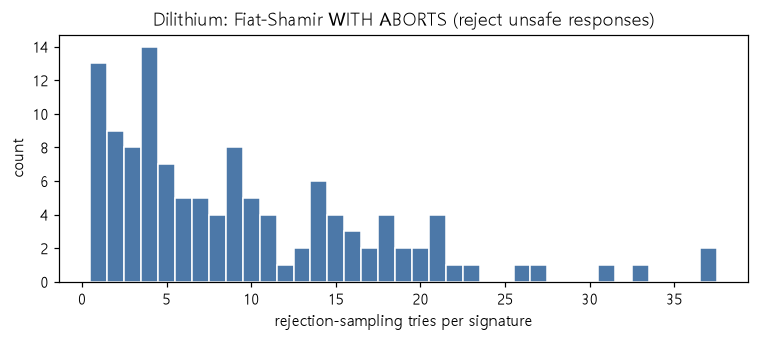

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.2))
maxt = max(tries_list)
ax.hist(tries_list, bins=range(1, maxt + 2), color='#4C78A8', edgecolor='white', align='left')
ax.set_xlabel('rejection-sampling tries per signature'); ax.set_ylabel('count')
ax.set_title('Dilithium: Fiat-Shamir WITH ABORTS (reject unsafe responses)')
plt.tight_layout(); plt.show()
log_metric('ML-DSA (Dilithium)', pk_bytes=nbytes(pk), sig_bytes=nbytes(sig),
           verify=good/T, forge_reject=forge_rej/T)

### 3-1. 그래프 해석

가로축은 도장(서명) 하나를 완성하기까지 찢고 다시 찍은(abort) 횟수, 세로축은 그런 서명이 몇 건이었는지입니다.

대부분의 서명은 왼쪽(적은 횟수)에 몰려 있고 오른쪽으로 갈수록 드물어집니다. "성공할 때까지 반복해서 뽑기"를 할 때 나오는 전형적인 모양(기하분포에 가까운 모양)입니다.
위 실측 기준으로 서명당 평균 **약 9.5회** 재시도했습니다.

> **재시도는 실패가 아니라 안전장치입니다.** 응답 z에 비밀 재료가 비쳐 보일 위험이 감지되면 그 도장을 찢고 새로 찍는 것으로,
> 안전을 위해 일부러 치르는 비용입니다. 이 설계 덕분에 공격자가 서명을 아무리 많이 모아도 비밀키를 거꾸로 알아낼 수 없습니다.

실무에서 Dilithium의 서명 생성 시간이 매번 조금씩 다른 것도 이 재시도 구조 때문이며, 정상 동작입니다.

### 3-2. 실무 적용성

- **측정**: 정상 서명은 전부 통과(120/120), 변조된 메시지는 전부 거부(120/120)됐습니다. 서명마다 평균 수 회의 재시도(abort)가 발생하며, 이것이 안전을 위해 치르는 비용입니다.
- **표준 현황**: 미국 표준 **FIPS 204 (ML-DSA)** 로 **2024년 8월 확정**되었고, NIST(미국 표준기술연구소)의 **1순위 권장 서명**입니다. 실제 ML-DSA-65 서명은 약 3.3 KB로, 지금 널리 쓰이는 RSA-3072 서명(~384 B)보다 큽니다.
- **적합처**: **코드 서명, 펌웨어/OTA 업데이트 서명, 인증서(PKI), 문서 서명** 등 한 번 만들어 오래 보관·검증하는 영역입니다. 이런 곳에서는 서명 크기보다 **미래에도 깨지지 않는 안전성**이 더 중요합니다.
- **자매 표준**: 서명 크기가 더 작아야 하면 **FN-DSA(Falcon, FIPS 206 예정)** 를, 격자라는 수학 가정 자체를 피하고 싶으면 해시 기반 **SLH-DSA(SPHINCS+)** 를 선택합니다.

> **핵심**: Dilithium(ML-DSA)은 양자 시대의 기본 서명 표준이며, "비밀이 비치면 찢고 다시 찍기(abort)"가 비밀키를 지키는 비결입니다.

## 연습문제

직접 코드를 고쳐 보면서 감을 잡아 보세요.

1. **"비쳐 보임" 판정의 여유 폭**: `DBETA` 를 48에서 96으로 키우면 "찢고 다시 찍기" 판정(`inf_norm(z) >= DGAMMA - DBETA`)이 더 엄격해집니다.
   평균 재시도 횟수가 어떻게 변하는지 실측하고, 반대로 24로 줄이면 왜 비밀이 새어 나갈 위험이 커지는지 설명해 보세요.

2. **가림막의 두께**: `DGAMMA` 를 1024에서 512로 줄여 실행해 보세요. 재시도 횟수가 어떻게 변하나요?
   가림막 y가 비밀 재료 쪽 값(c·s₁)을 덮어 가리는 역할과 연결해 이유를 설명해 보세요.

3. **상위 비트 반올림 단위**: `DGAMMA2` 를 128에서 64, 256으로 바꾸면 두 번째 중단 조건(상위 비트 불일치)의 발생 빈도와
   위조 거부율(120/120 유지 여부)이 어떻게 달라지는지 관찰해 보세요.

4. **변조 위치 실험**: 검증 실험에서 `msg + b'!'` 대신 메시지 **중간의 한 바이트**를 바꿔(예: `msg[:5] + b'X' + msg[6:]`) 위조를 시도해도
   여전히 전부 거부되는지 확인하고, 확인 질문 c가 메시지 전체의 해시(지문)로 만들어진다는 사실과 연결해 설명해 보세요.

## 요약

- 전자서명은 "위조할 수 없는 도장"으로, 인증(진짜 보낸 사람)·무결성(내용이 안 바뀜)·부인방지(발뺌 불가)를 제공합니다. ML-DSA(CRYSTALS-Dilithium)는 격자 문제 위에서 RSA·ECDSA를 대체하는 양자내성 서명입니다.
- 서명 구조는 **Fiat-Shamir with Aborts**: 응답 z = y + c·s₁(비밀 재료에 확인 질문을 섞고 가림막을 덮은 값)이 안전 범위를 벗어나면 **찢고 다시 찍어(abort)** 비밀키 누출을 차단합니다.
- 확인하는 쪽은 공개키와 서명만으로 도장 자국을 되살린 뒤, **HighBits(상위 비트만 비교)** 로 작은 오차는 눈감아 주면서 위조만 잡아냅니다.
- 크기를 줄인 연습용 파라미터 실험에서 정상 검증 120/120 통과, 변조 위조 120/120 거부, 서명당 평균 9.5회 재시도를 실측했습니다.
- **FIPS 204** 로 2024년 8월 확정된 NIST 1순위 권장 서명이며, 코드 서명·펌웨어·PKI 등 오래 보관·검증하는 영역에 적합합니다.
- 서명이 더 작아야 하면 FN-DSA(Falcon)를, 격자라는 수학 가정을 피하려면 해시 기반 SLH-DSA를 보완 표준으로 씁니다.

> 재시도(abort) 때문에 서명 시간이 매번 조금씩 달라지는 것은 결함이 아니라 설계입니다 — "위험하면 버리고 다시 찍는" 이 확률적 중단이야말로,
> 공격자가 서명을 아무리 수집해도 비밀키가 드러나지 않게 하는 Dilithium 안전성의 핵심 장치입니다.